# DATE3 实验4：无预取条件下的四级 Bank 映射对比

四组依次为旧架构固定 `5/5/5/15`、模型级最优固定划分、PIVOT动态映射消融，
以及相同需求流量下令全部片上Bank服务不暴露在关键路径上的Ideal-NoPF参考。所有方案
关闭预取；Ideal是不可实现的零暴露Bank服务下界，不是另一个硬件方案，也不能解释为
仅消除Bank冲突。


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'fig' else Path.cwd().resolve()
OUT = ROOT/'outputs/DATE3/exp4'; FIG = ROOT/'fig/DATE3'; FIG.mkdir(parents=True, exist_ok=True)
MODELS = ['HMoE', 'Mixtral', 'MoDSE', 'Switchtrans']
SCHEMES = ['Static-555-NoPF', 'Static-Opt-NoPF', 'Dynamic-NoPF', 'Ideal-NoPF']
LABELS = {'Static-555-NoPF':'Static-555', 'Static-Opt-NoPF':'Static-Opt',
          'Dynamic-NoPF':'PIVOT-Map', 'Ideal-NoPF':'Ideal'}
COLORS = {'Static-555-NoPF':'#9E9E9E', 'Static-Opt-NoPF':'#F28E2B',
          'Dynamic-NoPF':'#4E79A7', 'Ideal-NoPF':'#B07AA1'}
d = pd.read_csv(OUT/'mapping_comparison.csv')
assert len(d) == len(MODELS)*len(SCHEMES)
assert set(d.model) == set(MODELS) and set(d.policy_name) == set(SCHEMES)
assert not d.duplicated(['model','policy_name']).any()
assert d.prefetched_bytes.eq(0).all() and d.coverage.eq(0).all()

def wide(field):
    return d.pivot(index='model', columns='policy_name', values=field).reindex(MODELS, columns=SCHEMES)

total, stall = wide('total_cycles'), wide('local_memory_stall_cycles')
compute, detailed = wide('compute_cycles'), wide('detailed_ready_cycle')
peer, combine, result = wide('peer_ready_cycle'), wide('combine_cycles'), wide('result_ready_cycle')
assert compute.nunique(axis=1).eq(1).all()
assert peer.nunique(axis=1).eq(1).all() and combine.nunique(axis=1).eq(1).all()
assert np.array_equal(result.to_numpy(), np.maximum(detailed.to_numpy(), peer.to_numpy()))
assert np.array_equal(total.to_numpy(), result.to_numpy()+combine.to_numpy())
print(f'Loaded {len(d)} Exp4 rows from {OUT/"mapping_comparison.csv"}')


Loaded 16 Exp4 rows from /home/MikeNotFound/code/SCALE-Sim/outputs/DATE3/exp4/mapping_comparison.csv


## 4.1 四组性能与理论顺序

柱高为相对Static-555的周期，越低越好。Ideal使用空心柱强调其仅为参考。


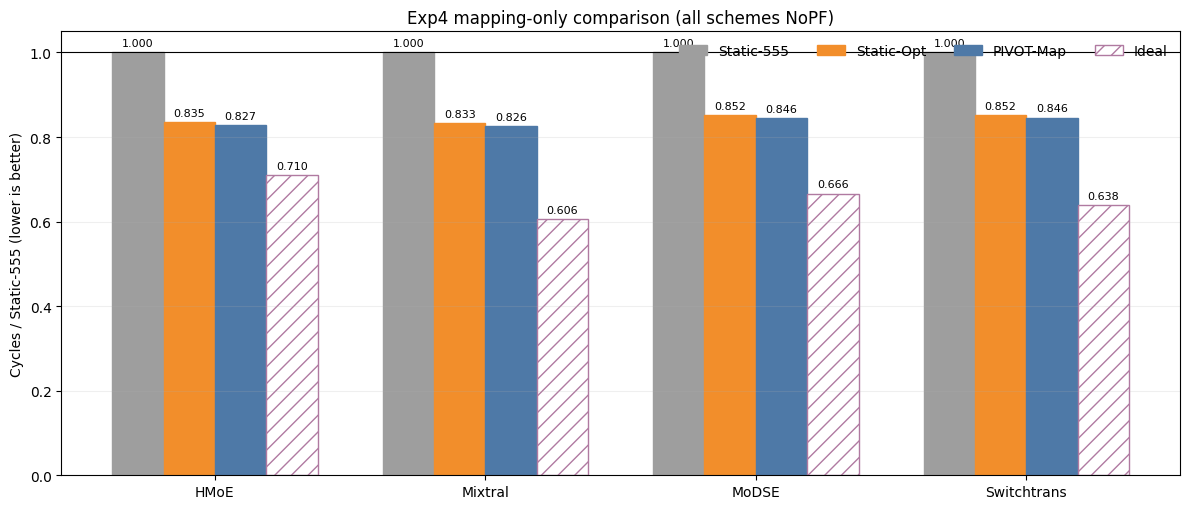

In [2]:
normalized = total.div(total['Static-555-NoPF'], axis=0)
x=np.arange(len(MODELS)); width=.19
fig, ax=plt.subplots(figsize=(12,5.2))
for i, scheme in enumerate(SCHEMES):
    bars=ax.bar(x+(i-1.5)*width, normalized[scheme], width,
                color='white' if scheme=='Ideal-NoPF' else COLORS[scheme],
                edgecolor=COLORS[scheme], hatch='//' if scheme=='Ideal-NoPF' else None,
                label=LABELS[scheme])
    ax.bar_label(bars, labels=[f'{v:.3f}' for v in normalized[scheme]], padding=3, fontsize=8)
ax.axhline(1,color='black',lw=.8); ax.set_xticks(x,MODELS)
ax.set_ylabel('Cycles / Static-555 (lower is better)')
ax.set_title('Exp4 mapping-only comparison (all schemes NoPF)')
ax.legend(ncol=4,frameon=False); ax.grid(axis='y',alpha=.2)
plt.tight_layout(); plt.savefig(FIG/'exp4_mapping_four_way.pdf',bbox_inches='tight'); plt.show()


### 图4(a)：四个网络上的 mapping-only normalized cycles，包含 Static-555、Static-Opt、Dynamic 和 Ideal。

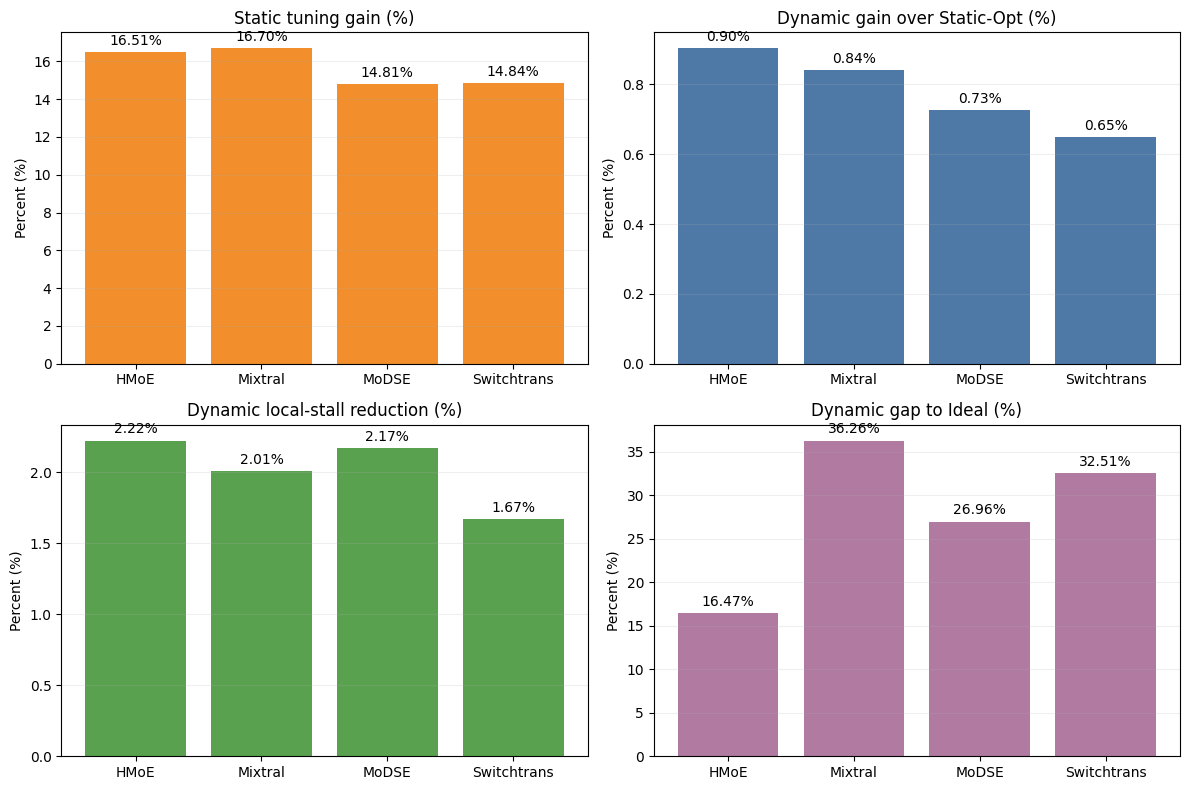

,Static tuning gain (%),Dynamic gain over Static-Opt (%),Dynamic local-stall reduction (%),Dynamic gap to Ideal (%)
model,,,,
HMoE,16.509,0.903,2.224,16.471
Mixtral,16.701,0.842,2.011,36.263
MoDSE,14.813,0.727,2.169,26.955
Switchtrans,14.843,0.650,1.670,32.513


In [3]:
gain_static = (1-total['Static-Opt-NoPF']/total['Static-555-NoPF'])*100
gain_dynamic = (1-total['Dynamic-NoPF']/total['Static-Opt-NoPF'])*100
gap_ideal = (total['Dynamic-NoPF']/total['Ideal-NoPF']-1)*100
gain_dynamic_local = (1-stall['Dynamic-NoPF']/stall['Static-Opt-NoPF'])*100
metrics=pd.DataFrame({'Static tuning gain (%)':gain_static,
                      'Dynamic gain over Static-Opt (%)':gain_dynamic,
                      'Dynamic local-stall reduction (%)':gain_dynamic_local,
                      'Dynamic gap to Ideal (%)':gap_ideal})
fig,axes=plt.subplots(2,2,figsize=(12,8.0))
for ax,(name,values),color in zip(axes.ravel(),metrics.items(),
                                  ['#F28E2B','#4E79A7','#59A14F','#B07AA1']):
    bars=ax.bar(MODELS,values,color=color); ax.bar_label(bars,labels=[f'{v:.2f}%' for v in values],padding=3)
    ax.set_title(name); ax.set_ylabel('Percent (%)'); ax.grid(axis='y',alpha=.2)
plt.tight_layout(); plt.savefig(FIG/'exp4_mapping_benefit_decomposition.pdf',bbox_inches='tight'); plt.show()
display(metrics.round(3))


## 4.2 访存停顿与EP关键路径

左图验证收益来自本地访存路径；右图说明局部收益是否被Peer NPU关键路径遮蔽。


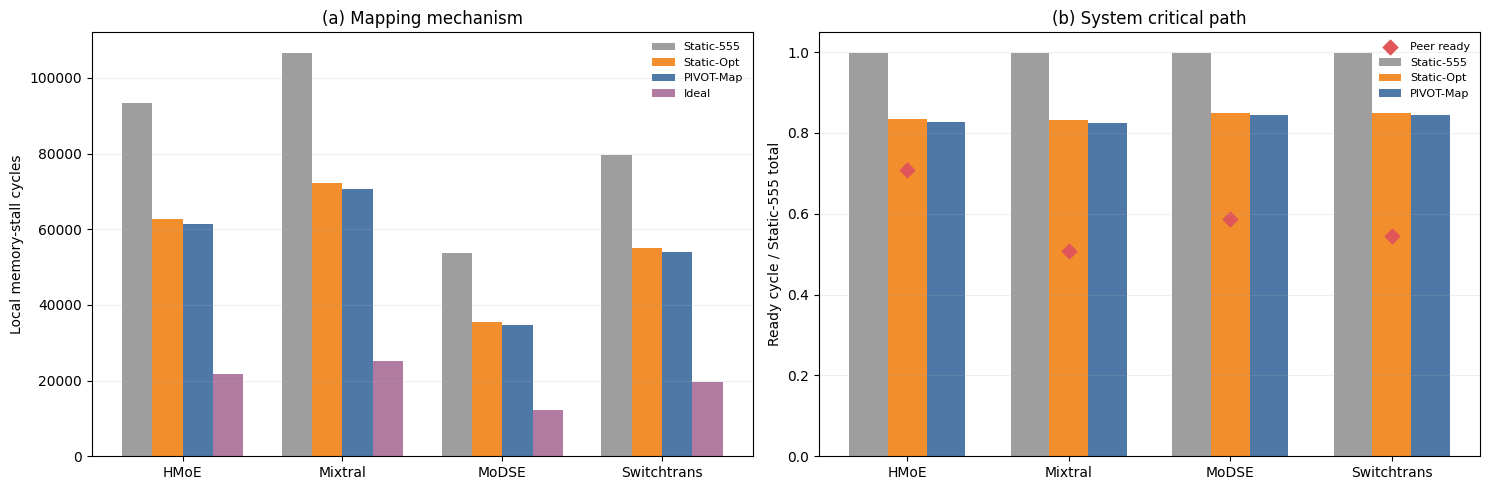

In [4]:
fig,axes=plt.subplots(1,2,figsize=(15,5.0)); x=np.arange(len(MODELS)); width=.19
for i,scheme in enumerate(SCHEMES):
    axes[0].bar(x+(i-1.5)*width,stall[scheme],width,color=COLORS[scheme],label=LABELS[scheme])
axes[0].set_xticks(x,MODELS); axes[0].set_ylabel('Local memory-stall cycles')
axes[0].set_title('(a) Mapping mechanism'); axes[0].legend(frameon=False,fontsize=8); axes[0].grid(axis='y',alpha=.2)
norm=total['Static-555-NoPF']
for i,scheme in enumerate(SCHEMES[:-1]):
    axes[1].bar(x+(i-1)*.24,detailed[scheme]/norm,.24,color=COLORS[scheme],label=LABELS[scheme])
axes[1].scatter(x,peer['Static-555-NoPF']/norm,marker='D',s=55,color='#E15759',label='Peer ready')
axes[1].set_xticks(x,MODELS); axes[1].set_ylabel('Ready cycle / Static-555 total')
axes[1].set_title('(b) System critical path'); axes[1].legend(frameon=False,fontsize=8); axes[1].grid(axis='y',alpha=.2)
plt.tight_layout(); plt.savefig(FIG/'exp4_mapping_stall_and_critical_path.pdf',bbox_inches='tight'); plt.show()


In [5]:
checks=pd.Series({
 'All four groups are NoPF': d.prefetched_bytes.eq(0).all(),
 'Static-Opt never exceeds Static-555': (total['Static-Opt-NoPF']<=total['Static-555-NoPF']).all(),
 'Dynamic strictly improves Static-Opt overall': (total['Dynamic-NoPF']<total['Static-Opt-NoPF']).all(),
 'Dynamic is measured, not Static-Opt fallback': d.loc[
     d.policy_name.eq('Dynamic-NoPF'),'candidate_source'
 ].eq('measured:model_guarded_stage_mapping').all(),
 'Ideal never exceeds Dynamic': (total['Ideal-NoPF']<=total['Dynamic-NoPF']).all(),
 'Compute/Peer/Combine are matched': (compute.nunique(axis=1).eq(1)&peer.nunique(axis=1).eq(1)&combine.nunique(axis=1).eq(1)).all(),
})
display(checks.rename('pass').to_frame()); assert checks.all()
summary=pd.concat({'cycles':total,'local_stall':stall},axis=1)
display(summary.astype(int))


,pass
All four groups are NoPF,True
Static-Opt never exceeds Static-555,True
Dynamic strictly improves Static-Opt overall,True
"Dynamic is measured, not Static-Opt fallback",True
Ideal never exceeds Dynamic,True
Compute/Peer/Combine are matched,True


cycles                                          \
policy_name Static-555-NoPF Static-Opt-NoPF Dynamic-NoPF Ideal-NoPF   
model                                                                 
HMoE                 185205          154629       153232     131562   
Mixtral              206968          172403       170952     125457   
MoDSE                124052          105676       104908      82634   
Switchtrans          166080          141429       140510     106035   

                local_stall                                          
policy_name Static-555-NoPF Static-Opt-NoPF Dynamic-NoPF Ideal-NoPF  
model                                                                
HMoE                  93393           62817        61420      21791  
Mixtral              106708           72143        70692      25197  
MoDSE                 53780           35404        34636      12362  
Switchtrans           79680           55029        54110      19635

## 论文使用边界

只有上述契约全部通过后，Exp4才支持“逐层动态映射在模型整体上优于最佳固定划分”的结论。
允许个别FFN层因跨层资源权衡略逊，但四个完整模型的总周期必须获得严格收益；不能再用
Static-Opt回退后的同值结果作为动态收益。
Ideal-NoPF令全部片上Bank服务在关键路径上零暴露，是不可实现下界；它不是“只消除冲突”
的可实现硬件，也不用于宣称PIVOT性能。
